# EDA Experimental Data
Clean starter notebook for exploratory analysis of the experimental dataset.


## 1) Setup
Run this first.


In [39]:
from importlib import reload
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import Experimental_Data.analyze_experimental_data as analysis
except ModuleNotFoundError as exc:
    if getattr(exc, 'name', '') != 'Experimental_Data':
        raise
    current_dir = Path('Experimental_Data').resolve()
    if str(current_dir) not in sys.path:
        sys.path.insert(0, str(current_dir))
    import analyze_experimental_data as analysis

analysis = reload(analysis)

# --------------------------
# EDA data source (global)
# --------------------------
EDA_USE_CUSTOM_MAT_FILES = True

# Folder mode (recommended)
EDA_CUSTOM_MAT_DIR = Path('CrossFlow/CleanedCorrectedData')
#EDA_CUSTOM_MAT_DIR = Path('CrossFlow/RawData')
EDA_CUSTOM_MAT_DIR_PATTERN = '*.mat'
EDA_CUSTOM_MAT_DIR_RECURSIVE = False
EDA_ONLY_USE_CUSTOM_DIR = True

# Optional file/glob mode (used only when EDA_ONLY_USE_CUSTOM_DIR=False)
EDA_CUSTOM_MAT_FILES = [
    # 'Experimental_Data/CrossFlow/RawData/test3003.mat',
]
EDA_CUSTOM_MAT_GLOB = None  # e.g. 'test300*.mat'
EDA_CUSTOM_GLOB_BASE_DIR = None

# Loader behavior
EDA_DATA_VARIABLE = 'data'  # raw MAT files in CrossFlow/RawData use variable 'data'
EDA_SKIP_UNREADABLE_FILES = False
EDA_PRINT_SELECTED_FILES_IN_PREP = True

# Keep analysis module in sync for all subsequent notebook cells.
analysis.DATA_VARIABLE = EDA_DATA_VARIABLE


def _to_abs_path(path_like: Path | str) -> Path:
    p = Path(path_like)
    if p.is_absolute():
        return p
    c1 = (Path.cwd() / p).resolve()
    if c1.exists():
        return c1
    c2 = (Path.cwd() / 'Experimental_Data' / p).resolve()
    if c2.exists():
        return c2
    return c1


def _resolve_eda_mat_files() -> tuple[list[Path], str]:
    if not bool(EDA_USE_CUSTOM_MAT_FILES):
        return analysis._resolve_mat_files(), 'analysis._resolve_mat_files() from analyze_experimental_data.py'

    selected_files: list[Path] = []
    use_dir_only = bool(EDA_ONLY_USE_CUSTOM_DIR) and (EDA_CUSTOM_MAT_DIR is not None)

    if not use_dir_only:
        for item in EDA_CUSTOM_MAT_FILES:
            selected_files.append(_to_abs_path(item))

        if EDA_CUSTOM_MAT_GLOB:
            base_dir = (
                Path(getattr(analysis, 'MAT_GLOB_BASE_DIR', '.'))
                if EDA_CUSTOM_GLOB_BASE_DIR is None
                else Path(EDA_CUSTOM_GLOB_BASE_DIR)
            )
            base_dir = _to_abs_path(base_dir)
            selected_files.extend(sorted(base_dir.glob(str(EDA_CUSTOM_MAT_GLOB))))

    if EDA_CUSTOM_MAT_DIR is not None:
        mat_dir = _to_abs_path(EDA_CUSTOM_MAT_DIR)
        if not mat_dir.exists() or not mat_dir.is_dir():
            raise FileNotFoundError(f'EDA_CUSTOM_MAT_DIR does not exist or is not a directory: {mat_dir}')
        pattern = str(EDA_CUSTOM_MAT_DIR_PATTERN) if EDA_CUSTOM_MAT_DIR_PATTERN else '*.mat'
        files = mat_dir.rglob(pattern) if bool(EDA_CUSTOM_MAT_DIR_RECURSIVE) else mat_dir.glob(pattern)
        selected_files.extend(sorted(files))

    # De-duplicate, keep order.
    out: list[Path] = []
    seen: set[str] = set()
    for p in selected_files:
        key = str(Path(p).resolve())
        if key in seen:
            continue
        seen.add(key)
        out.append(Path(key))

    if not out:
        raise ValueError('No MAT files selected. Check EDA_CUSTOM_MAT_DIR / EDA_CUSTOM_MAT_FILES / EDA_CUSTOM_MAT_GLOB.')

    missing = [p for p in out if not p.exists()]
    if missing:
        msg = 'Selected MAT file(s) not found:'
        for p in missing:
            msg += f'\n{p}'
        raise FileNotFoundError(msg)

    source = 'EDA custom selection (dir/files/glob)'
    if use_dir_only:
        source += ' [DIR ONLY ENFORCED]'
    return out, source


def _print_eda_mat_source_preview(max_items: int = 20) -> None:
    files, source = _resolve_eda_mat_files()
    print(f'EDA MAT source: {source}')
    print(f'EDA loader DATA_VARIABLE: {analysis.DATA_VARIABLE!r}')
    print(f'EDA selected {len(files)} file(s):')
    for i, p in enumerate(files):
        if i >= int(max_items):
            print(f' - ... ({len(files) - int(max_items)} more)')
            break
        print(f' - {p}')


_print_eda_mat_source_preview()


EDA MAT source: EDA custom selection (dir/files/glob) [DIR ONLY ENFORCED]
EDA loader DATA_VARIABLE: 'data'
EDA selected 10 file(s):
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3003.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3004.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3005.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3006.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3008.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3010_part1.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3010_part2.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedDa

## 2) Sanity Checks (Optional)
Use this to validate sampling and NaN patterns before analysis.


In [40]:
# Input sanity checks (uses the same MAT selection from 1) Setup)
RUN_SANITY_CHECKS = True
SANITY_SAMPLING_RTOL = 1e-3
SANITY_SAMPLING_ATOL = 1e-9
SANITY_MAX_PRINT_PER_COLUMN = 20


def _sampling_sanity(time_values, *, rtol, atol):
    t = np.asarray(time_values, dtype=float).reshape(-1)
    finite_mask = np.isfinite(t)
    time_nonfinite = int(np.count_nonzero(~finite_mask))
    t = t[finite_mask]

    if t.size < 2:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': False,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    dt = np.diff(t)
    monotonic = bool(np.all(dt > 0.0))
    dt = dt[(np.isfinite(dt)) & (dt > 0.0)]
    if dt.size == 0:
        return {
            'time_nonfinite': time_nonfinite,
            'monotonic_time': monotonic,
            'constant_sampling': False,
            'dt_median': np.nan,
            'max_rel_dt_dev': np.nan,
        }

    dt_med = float(np.median(dt))
    rel_dev = np.abs(dt - dt_med) / max(abs(dt_med), 1e-15)
    return {
        'time_nonfinite': time_nonfinite,
        'monotonic_time': monotonic,
        'constant_sampling': bool(np.all(np.isclose(dt, dt_med, rtol=rtol, atol=atol))),
        'dt_median': dt_med,
        'max_rel_dt_dev': float(np.max(rel_dev)),
    }


def _column_label(col_idx, channel_names):
    if channel_names is not None and 0 <= int(col_idx) < len(channel_names):
        name = str(channel_names[int(col_idx)]).strip()
        if name:
            return f'col {int(col_idx)} ({name})'
    return f'col {int(col_idx)}'


def _nan_column_time_report(data, time_values, channel_names, *, max_items=20):
    arr = np.asarray(data, dtype=float)
    if arr.ndim != 2:
        return []

    t = np.asarray(time_values, dtype=float).reshape(-1)
    has_time = t.size == arr.shape[0]
    lines = []

    for col_idx in range(arr.shape[1]):
        nan_idx = np.flatnonzero(np.isnan(arr[:, col_idx]))
        if nan_idx.size == 0:
            continue

        shown = nan_idx[: int(max_items)]
        samples = []
        for idx in shown:
            i = int(idx)
            if has_time and np.isfinite(t[i]):
                samples.append(f'(i={i}, t={float(t[i]):.6g})')
            elif has_time:
                samples.append(f'(i={i}, t=nonfinite)')
            else:
                samples.append(f'(i={i})')

        extra = '' if nan_idx.size <= int(max_items) else f' ... +{int(nan_idx.size - int(max_items))} more'
        lines.append(
            f"{_column_label(col_idx, channel_names)}: nan_count={int(nan_idx.size)} at "
            + ', '.join(samples)
            + extra
        )

    return lines


if RUN_SANITY_CHECKS:
    mat_files, mat_source_desc = _resolve_eda_mat_files()
    print(f'Sanity checks source: {mat_source_desc}')
    print(
        f"Sanity checks (sampling rtol={SANITY_SAMPLING_RTOL:g}, atol={SANITY_SAMPLING_ATOL:g})"
    )

    all_ok = True
    for mat_file in mat_files:
        try:
            data, channel_names = analysis._load_data_matrix(mat_file, analysis.DATA_VARIABLE)
        except Exception as exc:
            all_ok = False
            print(f'[FAIL] {mat_file.name}: could not load file ({exc})')
            continue

        total_count = int(data.size)
        matrix_nonfinite = int(total_count - np.count_nonzero(np.isfinite(data)))
        time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='sanity-check time')
        sampling = _sampling_sanity(
            time_raw,
            rtol=float(SANITY_SAMPLING_RTOL),
            atol=float(SANITY_SAMPLING_ATOL),
        )

        ok = (
            matrix_nonfinite == 0
            and int(sampling['time_nonfinite']) == 0
            and bool(sampling['monotonic_time'])
            and bool(sampling['constant_sampling'])
        )
        if not ok:
            all_ok = False
        status = 'OK' if ok else 'WARN'

        dt_txt = f"{sampling['dt_median']:.9g}" if np.isfinite(sampling['dt_median']) else 'n/a'
        rel_txt = f"{sampling['max_rel_dt_dev']:.3e}" if np.isfinite(sampling['max_rel_dt_dev']) else 'n/a'
        print(
            f"[{status}] {mat_file.name}: matrix_nonfinite={matrix_nonfinite}/{total_count}, "
            f"time_nonfinite={int(sampling['time_nonfinite'])}, "
            f"monotonic_time={bool(sampling['monotonic_time'])}, "
            f"constant_sampling={bool(sampling['constant_sampling'])}, "
            f"dt_median={dt_txt}, max_rel_dt_dev={rel_txt}"
        )

        for line in _nan_column_time_report(
            data,
            time_raw,
            channel_names,
            max_items=int(SANITY_MAX_PRINT_PER_COLUMN),
        ):
            print(f'  [NaN] {line}')

    if all_ok:
        print('Sanity checks passed for all selected files.')
    else:
        print('Sanity checks found issues in one or more selected files. Continuing.')


Sanity checks source: EDA custom selection (dir/files/glob) [DIR ONLY ENFORCED]
Sanity checks (sampling rtol=0.001, atol=1e-09)
[OK] test3003.mat: matrix_nonfinite=0/5806718, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3004.mat: matrix_nonfinite=0/8690734, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3005.mat: matrix_nonfinite=0/7081470, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3006.mat: matrix_nonfinite=0/11677192, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3008.mat: matrix_nonfinite=0/6033636, time_nonfinite=0, monotonic_time=True, constant_sampling=True, dt_median=0.005, max_rel_dt_dev=2.274e-11
[OK] test3010_part1.mat: matrix_nonfinite=0/5316500, time_nonfinite=0, monotonic_time=True, constant_sampling=T

## 3) Data Prep
Loads selected files into `entries` for downstream plotting.


In [41]:
# Data prep
PRINT_SUMMARY = True

mat_files, mat_source_desc = _resolve_eda_mat_files()
if bool(EDA_PRINT_SELECTED_FILES_IN_PREP):
    print(f'MAT files selected for EDA ({mat_source_desc}):')
    for p_item in mat_files:
        print(f' - {p_item}')

if bool(EDA_SKIP_UNREADABLE_FILES):
    entries = []
    skipped = []
    for p_item in mat_files:
        try:
            entries.append(analysis._process_file(p_item))
        except Exception as exc:
            skipped.append((p_item, exc))
    if skipped:
        print('\nSkipped unreadable MAT files:')
        for p_item, exc in skipped:
            print(f' - {p_item}: {type(exc).__name__}: {exc}')
    if not entries:
        raise RuntimeError('All selected MAT files failed to load.')
else:
    entries = [analysis._process_file(p) for p in mat_files]

colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(entries), 2)))
n_rows = len(entries)

if PRINT_SUMMARY:
    for entry in entries:
        s = entry['summary']
        print(
            f"{entry['label']}: Umean={s['umean']:.6f} m/s, Ur={s['ur']:.6f}, "
            f"Cd={s['cd']:.6f}, Ydomfreq={s['ydomfreq']:.6f} +/- {s['ydomfreq_std']:.6f} Hz, "
            f"nt={s['nt']}, dt={s['dt']:.6f} s, Fs={s['fs']:.6f} Hz, "
            f"coeff_norm={s['coeff_norm_mode']}"
        )
        if analysis.REMOVE_INERTIA_FROM_CF:
            print(
                f"{entry['label']}: applied inertia removal with "
                f"m_remove={s['m_inertia_removed']:.6f} kg "
                f"(M={analysis.M:.6f} kg, m_a={s['m_added']:.6f} kg, "
                f"include_m_a={analysis.INERTIA_INCLUDE_ADDED_MASS})"
            )

print(f'Loaded {len(entries)} entries from {len(mat_files)} selected file(s).')


MAT files selected for EDA (EDA custom selection (dir/files/glob) [DIR ONLY ENFORCED]):
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3003.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3004.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3005.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3006.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3008.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3010_part1.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3010_part2.mat
 - /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/CrossFlow/CleanedCorrectedData/test3011.mat
 - /Users/kasperslagstad/Des

## 4) Key Timeseries + End Histograms
Plots reduced velocity `U_r`, spring-force signal `Fy2-Fy1`, and displacement with a rotated histogram panel at the end of each timeseries.


/var/folders/45/0414q_nx25dcwfzhlc7w0gd80000gn/T/ipykernel_34789/1404149921.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_ts.tight_layout()


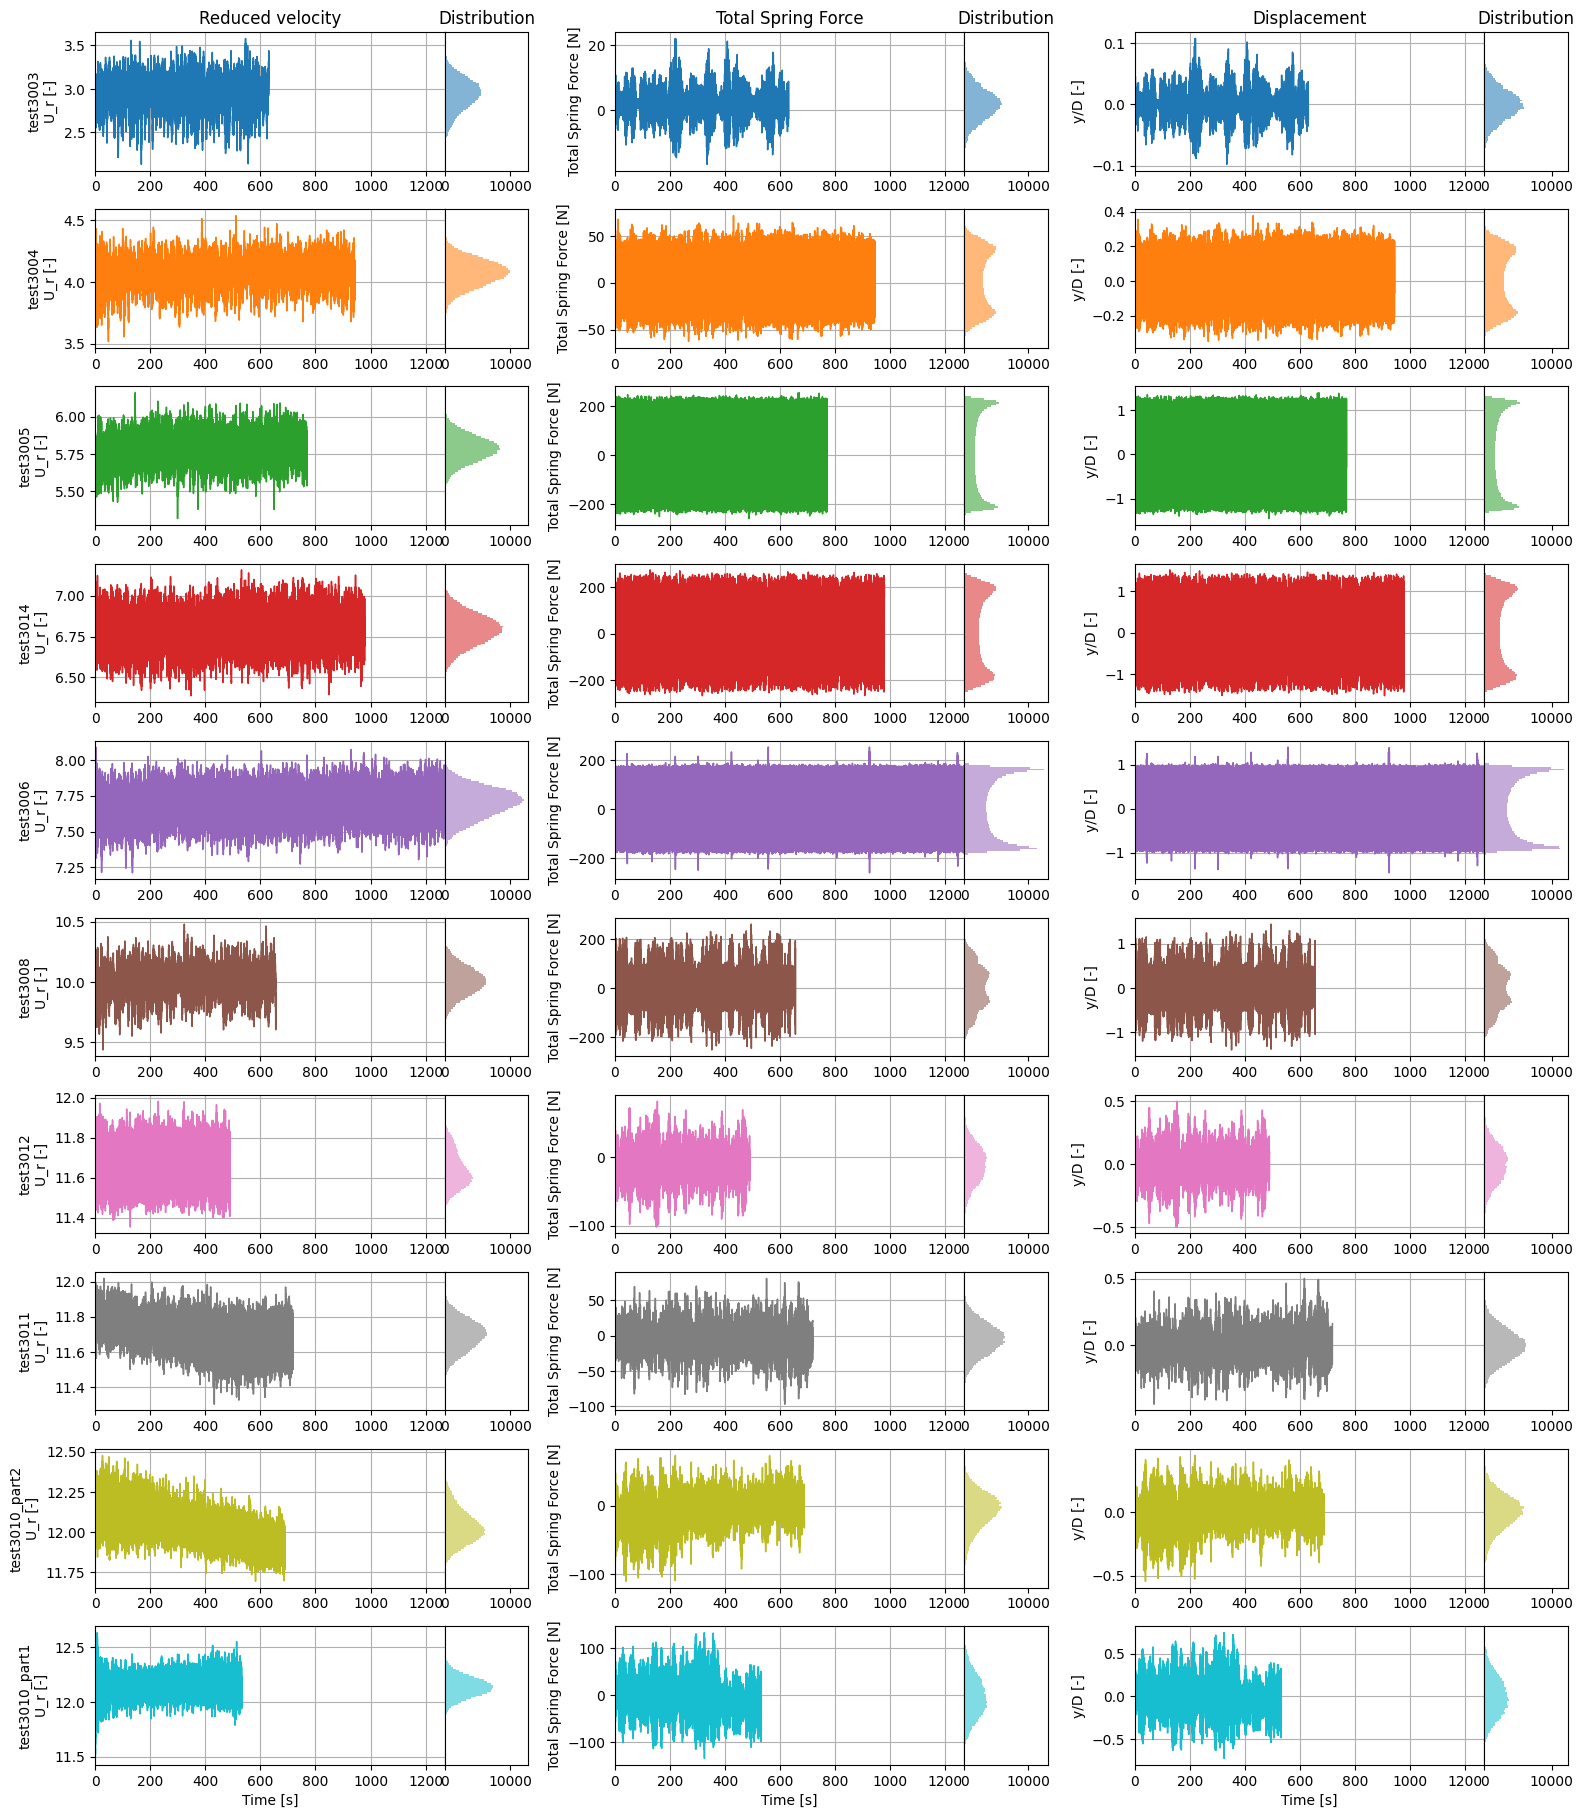

In [42]:
# Figure: U_r, raw Fy2-Fy1 from MAT, and displacement with right-side rotated histograms
TS_HIST_BINS = 70
TS_HIST_ALPHA = 0.55
TS_HIST_LINEWIDTH = 1.1
TS_HIST_FIG_W = 19
TS_HIST_ROW_H = 2.25
USE_NORMALIZED_DISPLACEMENT = True  # True -> y/D (mean removed), False -> raw displacement y (m)
SAVE_FIGURE_PNG = False
SAVE_FIGURE_PATH = Path('/Users/kasperslagstad/Desktop/Master-Thesis/Images/EDA/ExperimentalData/timeseries_raw.png')
SAVE_FIGURE_DPI = 300

# Layout control requested:
# - zero space inside each pair (timeseries <-> histogram)
# - large space between channel pairs
TS_PAIR_WSPACE = 0.00
TS_CHANNEL_GAP = 0.20
TS_ROW_GAP = 0.28

# Force requirement from user: use direct MAT channels only (no correction/scaling).
# Raw force = Fy2 - Fy1 = 9133_FORCE_4 - 9130_FORCE_1
_RAW_FORCE_CACHE = {}

def _mean_ur_for_sort(entry):
    ur = np.asarray(entry.get('ur_inst', []), dtype=float).reshape(-1)
    finite = ur[np.isfinite(ur)]
    if finite.size == 0:
        return float('inf')
    return float(np.mean(finite))

ordered_entries = sorted(entries, key=_mean_ur_for_sort)



def _raw_fy2_minus_fy1_series(entry):
    path = Path(entry['path']).resolve()
    key = str(path)
    if key in _RAW_FORCE_CACHE:
        return _RAW_FORCE_CACHE[key]

    data, channel_names = analysis._load_data_matrix(path, analysis.DATA_VARIABLE)

    # Use channel names when available; fallback to legacy column positions.
    fy1_fallback = 6 if data.shape[1] > 6 else max(0, data.shape[1] - 2)
    fy2_fallback = 9 if data.shape[1] > 9 else max(0, data.shape[1] - 1)

    time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='raw force time')
    fy1_raw = analysis._select_column(
        data,
        channel_names,
        ['9130_FORCE_1', 'Fy_spring1', 'fy_spring1'],
        fy1_fallback,
        role='raw Fy1',
    )
    fy2_raw = analysis._select_column(
        data,
        channel_names,
        ['9133_FORCE_4', 'Fy_spring2', 'fy_spring2'],
        fy2_fallback,
        role='raw Fy2',
    )

    time_arr = analysis._fill_nonfinite_1d(np.asarray(time_raw, dtype=float), role=f'{path.name}: time')
    fy1_arr = analysis._fill_nonfinite_1d(np.asarray(fy1_raw, dtype=float), role=f'{path.name}: Fy1')
    fy2_arr = analysis._fill_nonfinite_1d(np.asarray(fy2_raw, dtype=float), role=f'{path.name}: Fy2')

    n = int(min(time_arr.size, fy1_arr.size, fy2_arr.size))
    time_arr = np.asarray(time_arr[:n], dtype=float)
    force_raw = np.asarray(fy2_arr[:n] - fy1_arr[:n], dtype=float)

    trim_mask = analysis._time_trim_mask(
        time_arr,
        role=f'{path.name}: raw force trim',
        trim_start_seconds=float(getattr(analysis, 'TRIM_START_SECONDS', 0.0)),
        trim_end_seconds=float(getattr(analysis, 'TRIM_END_SECONDS', 0.0)),
    )
    time_arr = np.asarray(time_arr[trim_mask], dtype=float)
    force_raw = np.asarray(force_raw[trim_mask], dtype=float)

    if bool(getattr(analysis, 'USE_RELATIVE_TIME', True)) and time_arr.size > 0:
        time_plot = np.asarray(time_arr - float(time_arr[0]), dtype=float)
    else:
        time_plot = np.asarray(time_arr, dtype=float)

    _RAW_FORCE_CACHE[key] = (time_plot, force_raw)
    return _RAW_FORCE_CACHE[key]


n_rows = len(ordered_entries)
fig_ts = plt.figure(figsize=(TS_HIST_FIG_W, max(TS_HIST_ROW_H * n_rows, 2.8)))
outer = fig_ts.add_gridspec(
    n_rows,
    3,
    wspace=TS_CHANNEL_GAP,
    hspace=TS_ROW_GAP,
)

# axes_ts[row, col] where cols are:
# 0 line U_r, 1 hist U_r, 2 line force, 3 hist force, 4 line disp, 5 hist disp
axes_ts = np.empty((n_rows, 6), dtype=object)
line_refs = [None, None, None]
hist_refs = [None, None, None]

for i in range(n_rows):
    for g in range(3):
        sub = outer[i, g].subgridspec(1, 2, width_ratios=[4.8, 1.15], wspace=TS_PAIR_WSPACE)
        if line_refs[g] is None:
            ax_line = fig_ts.add_subplot(sub[0, 0])
            ax_hist = fig_ts.add_subplot(sub[0, 1])
            line_refs[g] = ax_line
            hist_refs[g] = ax_hist
        else:
            ax_line = fig_ts.add_subplot(sub[0, 0], sharex=line_refs[g])
            ax_hist = fig_ts.add_subplot(sub[0, 1], sharex=hist_refs[g])
        axes_ts[i, 2 * g] = ax_line
        axes_ts[i, 2 * g + 1] = ax_hist

# Titles on first row
axes_ts[0, 0].set_title('Reduced velocity')
axes_ts[0, 1].set_title('Distribution')
axes_ts[0, 2].set_title('Total Spring Force')
axes_ts[0, 3].set_title('Distribution')
axes_ts[0, 4].set_title('Displacement')
axes_ts[0, 5].set_title('Distribution')

for i, entry in enumerate(ordered_entries):
    color = colors[i % len(colors)]
    label = str(entry['label'])

    t_raw_force, fy_raw = _raw_fy2_minus_fy1_series(entry)
    ur = np.asarray(entry['ur_inst'], dtype=float)

    if USE_NORMALIZED_DISPLACEMENT:
        disp = np.asarray(entry['y_nd'], dtype=float)
        disp_ylabel = 'y/D (-)'
    else:
        disp = np.asarray(entry['y'], dtype=float)
        disp_ylabel = 'y (m)'

    n = int(min(t_raw_force.size, ur.size, fy_raw.size, disp.size))
    if n < 2:
        continue
    t = np.asarray(t_raw_force[:n], dtype=float)

    series = [
        (np.asarray(ur[:n], dtype=float), 'U_r [-]'),
        (np.asarray(fy_raw[:n], dtype=float), 'Total Spring Force [N]'),
        (np.asarray(disp[:n], dtype=float), "y/D [-]"),
    ]

    for k, (vals, ylab) in enumerate(series):
        ax_ts = axes_ts[i, 2 * k]
        ax_hist = axes_ts[i, 2 * k + 1]

        finite = np.isfinite(t) & np.isfinite(vals)
        t_plot = t[finite]
        v_plot = vals[finite]
        if t_plot.size == 0:
            continue

        ax_ts.plot(t_plot, v_plot, color=color, linewidth=TS_HIST_LINEWIDTH)
        ax_ts.margins(x=0)
        ax_ts.grid(True)
        if k == 0:
            ax_ts.set_ylabel(f"{label}\n{ylab}")
        else:
            ax_ts.set_ylabel(ylab)

        ax_hist.hist(
            v_plot,
            bins=int(TS_HIST_BINS),
            orientation='horizontal',
            color=color,
            alpha=TS_HIST_ALPHA,
            edgecolor='none',
        )
        ax_hist.set_ylim(ax_ts.get_ylim())
        ax_hist.grid(True, axis='y', alpha=0.35)
        ax_hist.set_xlabel('')
        ax_hist.set_yticks([])
        ax_hist.set_yticklabels([])
        ax_hist.tick_params(axis='y', left=False)
        ax_hist.spines['left'].set_visible(True)

for j in [0, 2, 4]:
    axes_ts[-1, j].set_xlabel('Time [s]')
for j in [1, 3, 5]:
    axes_ts[-1, j].set_xlabel('')

fig_ts.tight_layout()
if bool(SAVE_FIGURE_PNG):
    save_path = Path(SAVE_FIGURE_PATH)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig_ts.savefig(save_path, dpi=int(SAVE_FIGURE_DPI), bbox_inches='tight')
    print(f'Saved figure to {save_path.resolve()}')
plt.show()


## 5) Timeseries Summary Statistics\n

In [43]:
# Table: mean/std for U_r, displacement, and raw spring force (Fy2 - Fy1)
SUMMARY_USE_NORMALIZED_DISPLACEMENT = globals().get('USE_NORMALIZED_DISPLACEMENT', True)
SUMMARY_DECIMALS = 4

# Reuse helper from section 4 when available; define local fallback otherwise.
if '_raw_fy2_minus_fy1_series' not in globals():
    _RAW_FORCE_CACHE_LOCAL = {}

    def _raw_fy2_minus_fy1_series(entry):
        path = Path(entry['path']).resolve()
        key = str(path)
        if key in _RAW_FORCE_CACHE_LOCAL:
            return _RAW_FORCE_CACHE_LOCAL[key]

        data, channel_names = analysis._load_data_matrix(path, analysis.DATA_VARIABLE)
        fy1_fallback = 6 if data.shape[1] > 6 else max(0, data.shape[1] - 2)
        fy2_fallback = 9 if data.shape[1] > 9 else max(0, data.shape[1] - 1)

        time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='stats raw force time')
        fy1_raw = analysis._select_column(
            data,
            channel_names,
            ['9130_FORCE_1', 'Fy_spring1', 'fy_spring1'],
            fy1_fallback,
            role='stats raw Fy1',
        )
        fy2_raw = analysis._select_column(
            data,
            channel_names,
            ['9133_FORCE_4', 'Fy_spring2', 'fy_spring2'],
            fy2_fallback,
            role='stats raw Fy2',
        )

        t = analysis._fill_nonfinite_1d(np.asarray(time_raw, dtype=float), role=f'{path.name}: time')
        fy1 = analysis._fill_nonfinite_1d(np.asarray(fy1_raw, dtype=float), role=f'{path.name}: Fy1')
        fy2 = analysis._fill_nonfinite_1d(np.asarray(fy2_raw, dtype=float), role=f'{path.name}: Fy2')

        n = int(min(t.size, fy1.size, fy2.size))
        t = np.asarray(t[:n], dtype=float)
        fy = np.asarray(fy2[:n] - fy1[:n], dtype=float)

        trim_mask = analysis._time_trim_mask(
            t,
            role=f'{path.name}: stats raw force trim',
            trim_start_seconds=float(getattr(analysis, 'TRIM_START_SECONDS', 0.0)),
            trim_end_seconds=float(getattr(analysis, 'TRIM_END_SECONDS', 0.0)),
        )
        t = np.asarray(t[trim_mask], dtype=float)
        fy = np.asarray(fy[trim_mask], dtype=float)

        if bool(getattr(analysis, 'USE_RELATIVE_TIME', True)) and t.size > 0:
            t = np.asarray(t - float(t[0]), dtype=float)

        _RAW_FORCE_CACHE_LOCAL[key] = (t, fy)
        return _RAW_FORCE_CACHE_LOCAL[key]


def _mean_std(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan, np.nan
    return float(np.mean(arr)), float(np.std(arr))

ordered = sorted(
    entries,
    key=lambda e: float(np.nanmean(np.asarray(e.get('ur_inst', []), dtype=float)))
)

rows = []
for entry in ordered:
    label = str(entry['label'])
    _, fy_raw = _raw_fy2_minus_fy1_series(entry)
    ur = np.asarray(entry['ur_inst'], dtype=float)
    disp = np.asarray(entry['y_nd'] if SUMMARY_USE_NORMALIZED_DISPLACEMENT else entry['y'], dtype=float)

    n = int(min(ur.size, disp.size, fy_raw.size))
    ur = ur[:n]
    disp = disp[:n]
    fy = fy_raw[:n]

    ur_mean, ur_std = _mean_std(ur)
    disp_mean, disp_std = _mean_std(disp)
    fy_mean, fy_std = _mean_std(fy)

    rows.append({
        'Test': label,
        'U_r mean': ur_mean,
        'U_r std': ur_std,
        ('y/D mean' if SUMMARY_USE_NORMALIZED_DISPLACEMENT else 'y mean [m]'): disp_mean,
        ('y/D std' if SUMMARY_USE_NORMALIZED_DISPLACEMENT else 'y std [m]'): disp_std,
        'Spring Force mean [N]': fy_mean,
        'Spring Force std [N]': fy_std,
    })

try:
    import pandas as pd
    stats_df = pd.DataFrame(rows)
    numeric_cols = [c for c in stats_df.columns if c != 'Test']
    stats_df[numeric_cols] = stats_df[numeric_cols].astype(float).round(int(SUMMARY_DECIMALS))
    display(stats_df)
except Exception:
    # Fallback table print if pandas/display are unavailable.
    if not rows:
        print('No rows to display.')
    else:
        headers = list(rows[0].keys())
        print(' | '.join(headers))
        print('-' * (len(' | '.join(headers))))
        for r in rows:
            vals = []
            for h in headers:
                v = r[h]
                if isinstance(v, float):
                    vals.append(f'{v:.{int(SUMMARY_DECIMALS)}f}')
                else:
                    vals.append(str(v))
            print(' | '.join(vals))


,Test,U_r mean,U_r std,y/D mean,y/D std,Spring Force mean [N],Spring Force std [N]
0,test3003,2.9344,0.1899,-0.0,0.0268,1.9347,5.0200
1,test3004,4.0735,0.1123,0.0,0.1620,2.1218,29.8963
2,test3005,5.7834,0.0897,-0.0,0.8619,3.6815,156.0001
3,test3014,6.7928,0.0981,-0.0,0.8414,4.3152,151.0734
4,test3006,7.7002,0.1060,0.0,0.6625,1.3864,119.5975
5,test3008,10.0058,0.1236,-0.0,0.4916,1.1682,88.8116
6,test3012,11.6424,0.0906,0.0,0.1522,-9.8975,27.9548
7,test3011,11.6963,0.0891,0.0,0.1248,-4.9699,22.8785
8,test3010_part2,12.0361,0.1072,0.0,0.1420,-7.0708,26.8361
9,test3010_part1,12.1370,0.0989,0.0,0.2352,-2.7508,43.4480


## 6) Constructed Hydrodynamic Force + End Histograms


/var/folders/45/0414q_nx25dcwfzhlc7w0gd80000gn/T/ipykernel_34789/2948089348.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_h.tight_layout()


Constructed force uses M=16.7900 kg, m_a=8.0503 kg, (M+m_a)=24.8403 kg
Saved figure to /Users/kasperslagstad/Desktop/Master-Thesis/Images/EDA/ExperimentalData/timeseries_hydrodynamic_force_corrected.png


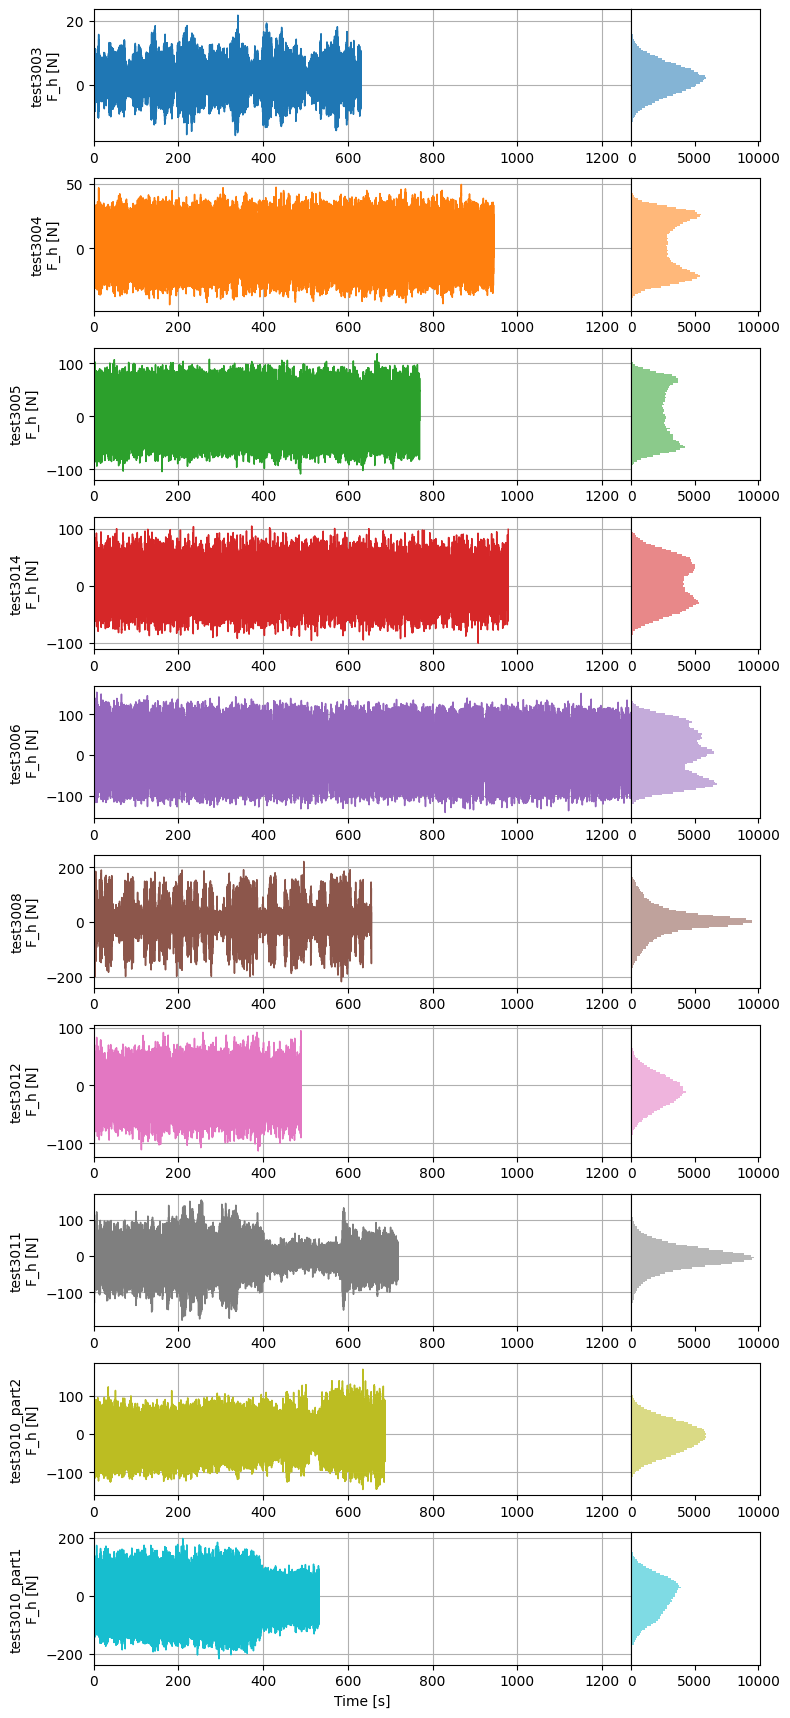

In [45]:
# Figure: constructed hydrodynamic force F_h = (Fy2 - Fy1) + (M + m_a) * y_ddot
HYDRO_HIST_BINS = 70
HYDRO_HIST_ALPHA = 0.55
HYDRO_LINEWIDTH = 1.1
HYDRO_FIG_W = 8.6
HYDRO_ROW_H = 2.15
HYDRO_PAIR_WSPACE = 0.00
HYDRO_ROW_GAP = 0.28

SAVE_HYDRO_FIGURE_PNG = True
SAVE_HYDRO_FIGURE_PATH = Path('/Users/kasperslagstad/Desktop/Master-Thesis/Images/EDA/ExperimentalData/timeseries_hydrodynamic_force_corrected.png')
SAVE_HYDRO_FIGURE_DPI = 300

# Reuse helper from the previous cell when available; define a local version otherwise.
if '_raw_fy2_minus_fy1_series' not in globals():
    _RAW_FORCE_CACHE_LOCAL = {}

    def _raw_fy2_minus_fy1_series(entry):
        path = Path(entry['path']).resolve()
        key = str(path)
        if key in _RAW_FORCE_CACHE_LOCAL:
            return _RAW_FORCE_CACHE_LOCAL[key]

        data, channel_names = analysis._load_data_matrix(path, analysis.DATA_VARIABLE)

        fy1_fallback = 6 if data.shape[1] > 6 else max(0, data.shape[1] - 2)
        fy2_fallback = 9 if data.shape[1] > 9 else max(0, data.shape[1] - 1)

        time_raw = analysis._select_column(data, channel_names, ['time', 'Time'], 0, role='raw force time')
        fy1_raw = analysis._select_column(
            data,
            channel_names,
            ['9130_FORCE_1', 'Fy_spring1', 'fy_spring1'],
            fy1_fallback,
            role='raw Fy1',
        )
        fy2_raw = analysis._select_column(
            data,
            channel_names,
            ['9133_FORCE_4', 'Fy_spring2', 'fy_spring2'],
            fy2_fallback,
            role='raw Fy2',
        )

        time_arr = analysis._fill_nonfinite_1d(np.asarray(time_raw, dtype=float), role=f'{path.name}: time')
        fy1_arr = analysis._fill_nonfinite_1d(np.asarray(fy1_raw, dtype=float), role=f'{path.name}: Fy1')
        fy2_arr = analysis._fill_nonfinite_1d(np.asarray(fy2_raw, dtype=float), role=f'{path.name}: Fy2')

        n = int(min(time_arr.size, fy1_arr.size, fy2_arr.size))
        time_arr = np.asarray(time_arr[:n], dtype=float)
        force_raw = np.asarray(fy2_arr[:n] - fy1_arr[:n], dtype=float)

        trim_mask = analysis._time_trim_mask(
            time_arr,
            role=f'{path.name}: raw force trim',
            trim_start_seconds=float(getattr(analysis, 'TRIM_START_SECONDS', 0.0)),
            trim_end_seconds=float(getattr(analysis, 'TRIM_END_SECONDS', 0.0)),
        )
        time_arr = np.asarray(time_arr[trim_mask], dtype=float)
        force_raw = np.asarray(force_raw[trim_mask], dtype=float)

        if bool(getattr(analysis, 'USE_RELATIVE_TIME', True)) and time_arr.size > 0:
            time_plot = np.asarray(time_arr - float(time_arr[0]), dtype=float)
        else:
            time_plot = np.asarray(time_arr, dtype=float)

        _RAW_FORCE_CACHE_LOCAL[key] = (time_plot, force_raw)
        return _RAW_FORCE_CACHE_LOCAL[key]


m_struct = float(getattr(analysis, 'M', 0.0))
m_added = float(getattr(analysis, 'ADDED_MASS_COEFF', 0.0)) * 0.25 * np.pi * float(getattr(analysis, 'RUO', 0.0)) * float(getattr(analysis, 'D', 0.0)) ** 2 * float(getattr(analysis, 'L', 0.0))
m_total = m_struct + m_added

if 'ordered_entries' in globals() and isinstance(ordered_entries, list) and len(ordered_entries) == len(entries):
    ordered_entries_h = ordered_entries
else:
    def _mean_ur_for_sort(entry):
        ur = np.asarray(entry.get('ur_inst', []), dtype=float).reshape(-1)
        finite = ur[np.isfinite(ur)]
        if finite.size == 0:
            return float('inf')
        return float(np.mean(finite))

    ordered_entries_h = sorted(entries, key=_mean_ur_for_sort)

n_rows = len(ordered_entries_h)
fig_h = plt.figure(figsize=(HYDRO_FIG_W, max(HYDRO_ROW_H * n_rows, 2.8)))
gs_h = fig_h.add_gridspec(n_rows, 2, width_ratios=[4.8, 1.15], wspace=HYDRO_PAIR_WSPACE, hspace=HYDRO_ROW_GAP)

ax_line_ref = None
ax_hist_ref = None
axes_h = np.empty((n_rows, 2), dtype=object)

for i in range(n_rows):
    if ax_line_ref is None:
        ax_line = fig_h.add_subplot(gs_h[i, 0])
        ax_hist = fig_h.add_subplot(gs_h[i, 1])
        ax_line_ref = ax_line
        ax_hist_ref = ax_hist
    else:
        ax_line = fig_h.add_subplot(gs_h[i, 0], sharex=ax_line_ref)
        ax_hist = fig_h.add_subplot(gs_h[i, 1], sharex=ax_hist_ref)
    axes_h[i, 0] = ax_line
    axes_h[i, 1] = ax_hist


for i, entry in enumerate(ordered_entries_h):
    color = colors[i % len(colors)]
    label = str(entry['label'])

    t_raw_force, fy_raw = _raw_fy2_minus_fy1_series(entry)
    ydd = np.asarray(entry['yacc'], dtype=float)

    n = int(min(t_raw_force.size, fy_raw.size, ydd.size))
    if n < 2:
        continue

    t = np.asarray(t_raw_force[:n], dtype=float)
    f_h = np.asarray(fy_raw[:n] + m_total * ydd[:n], dtype=float)

    finite = np.isfinite(t) & np.isfinite(f_h)
    t_plot = t[finite]
    f_plot = f_h[finite]
    if t_plot.size == 0:
        continue

    ax_ts = axes_h[i, 0]
    ax_hist = axes_h[i, 1]

    ax_ts.plot(t_plot, f_plot, color=color, linewidth=HYDRO_LINEWIDTH)
    ax_ts.margins(x=0)
    ax_ts.grid(True)
    ax_ts.set_ylabel(f"{label}\nF_h [N]")

    ax_hist.hist(
        f_plot,
        bins=int(HYDRO_HIST_BINS),
        orientation='horizontal',
        color=color,
        alpha=HYDRO_HIST_ALPHA,
        edgecolor='none',
    )
    ax_hist.set_ylim(ax_ts.get_ylim())
    ax_hist.grid(True, axis='y', alpha=0.35)
    ax_hist.set_xlabel('')
    ax_hist.set_ylabel('')
    ax_hist.set_yticks([])
    ax_hist.set_yticklabels([])
    ax_hist.tick_params(axis='y', left=False)
    ax_hist.spines['left'].set_visible(True)

axes_h[-1, 0].set_xlabel('Time [s]')
axes_h[-1, 1].set_xlabel('')

fig_h.tight_layout()
print(f"Constructed force uses M={m_struct:.4f} kg, m_a={m_added:.4f} kg, (M+m_a)={m_total:.4f} kg")
if bool(SAVE_HYDRO_FIGURE_PNG):
    save_path = Path(SAVE_HYDRO_FIGURE_PATH)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig_h.savefig(save_path, dpi=int(SAVE_HYDRO_FIGURE_DPI), bbox_inches='tight')
    print(f'Saved figure to {save_path.resolve()}')
plt.show()
